# 03. Modelo final: clasificación con transferencia de aprendizaje

Este notebook implementa el modelo final del proyecto para clasificar frutas frescas y podridas.

A diferencia del baseline clásico, aquí se utiliza una red neuronal convolucional preentrenada y se adapta a la tarea específica mediante fine-tuning.

Objetivo: superar el desempeño del modelo HOG + SVM y dejar un modelo final más robusto y defendible para el informe.

In [1]:
from pathlib import Path
import os
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from torchvision.models import EfficientNet_B0_Weights
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')

Dispositivo: cpu


In [2]:
project_root_candidates = [
    Path.cwd(),
    Path.cwd().parent,
    Path(r'C:\Users\alfam\proyPercepcion'),
]
project_root = None
for candidate in project_root_candidates:
    if (candidate / 'data' / 'train').exists() and (candidate / 'data' / 'test').exists():
        project_root = candidate
        break

if project_root is None:
    project_root = Path(r'C:\Users\alfam\proyPercepcion')

train_dir = project_root / 'data' / 'train'
test_dir = project_root / 'data' / 'test'
models_dir = project_root / 'models'
models_dir.mkdir(exist_ok=True)

print(f'Ruta del proyecto: {project_root}')
print(f'Train existe: {train_dir.exists()}')
print(f'Test existe: {test_dir.exists()}')
print(f'Modelos en: {models_dir}')

Ruta del proyecto: c:\Users\alfam\proyPercepcion
Train existe: True
Test existe: True
Modelos en: c:\Users\alfam\proyPercepcion\models


In [3]:
img_size = 224
batch_size = 32
num_workers = 0

train_transforms = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transforms = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

print('Transformaciones definidas correctamente.')

Transformaciones definidas correctamente.


In [4]:
if train_dir.exists() and test_dir.exists():
    full_train_dataset = datasets.ImageFolder(root=str(train_dir), transform=train_transforms)
    test_dataset = datasets.ImageFolder(root=str(test_dir), transform=eval_transforms)

    class_names = full_train_dataset.classes
    print(f'Clases: {class_names}')
    print(f'Entrenamiento total: {len(full_train_dataset)}')
    print(f'Test total: {len(test_dataset)}')

    targets = np.array(full_train_dataset.targets)
    indices = np.arange(len(full_train_dataset))
    train_idx, val_idx = train_test_split(
        indices,
        test_size=0.2,
        random_state=42,
        stratify=targets
    )

    train_dataset = Subset(full_train_dataset, train_idx)
    val_dataset = Subset(datasets.ImageFolder(root=str(train_dir), transform=eval_transforms), val_idx)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

    print(f'Train split: {len(train_dataset)}')
    print(f'Validation split: {len(val_dataset)}')
else:
    print('No se encontró data/train o data/test.')

Clases: ['freshapples', 'freshbanana', 'freshoranges', 'rottenapples', 'rottenbanana', 'rottenoranges']
Entrenamiento total: 10901
Test total: 2698
Train split: 8720
Validation split: 2181


In [5]:
def build_model(num_classes):
    """Construye el modelo final a partir de EfficientNet-B0 preentrenada."""
    weights = EfficientNet_B0_Weights.DEFAULT
    model = models.efficientnet_b0(weights=weights)

    for param in model.features.parameters():
        param.requires_grad = False

    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, num_classes)
    )
    return model

if train_dir.exists() and test_dir.exists():
    model = build_model(num_classes=len(class_names)).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.classifier.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=2, factor=0.5)
    print(model)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\alfam/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100.0%


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          

In [6]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    running_loss = 0.0
    all_preds = []
    all_targets = []

    for inputs, targets in loader:
        inputs = inputs.to(device)
        targets = targets.to(device)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            preds = torch.argmax(outputs, dim=1)

            if is_train:
                loss.backward()
                optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        all_preds.extend(preds.detach().cpu().numpy())
        all_targets.extend(targets.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_targets, all_preds)
    return epoch_loss, epoch_acc

if train_dir.exists() and test_dir.exists():
    num_epochs = 8
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }
    best_val_acc = 0.0
    best_model_path = models_dir / 'modelo_final_efficientnetb0.pth'

    start_time = time.time()
    for epoch in range(num_epochs):
        train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = run_epoch(model, val_loader, criterion)
        scheduler.step(val_acc)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f'Epoch {epoch + 1}/{num_epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}')

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                'model_state_dict': model.state_dict(),
                'class_names': class_names,
                'img_size': img_size
            }, best_model_path)

    elapsed_minutes = (time.time() - start_time) / 60
    print(f'Entrenamiento finalizado en {elapsed_minutes:.2f} minutos')
    print(f'Mejor accuracy de validación: {best_val_acc:.4f}')
    print(f'Modelo guardado en: {best_model_path}')

Epoch 1/8 | Train Loss: 0.4454 | Train Acc: 0.8969 | Val Loss: 0.1967 | Val Acc: 0.9583
Epoch 2/8 | Train Loss: 0.1941 | Train Acc: 0.9448 | Val Loss: 0.1263 | Val Acc: 0.9702
Epoch 3/8 | Train Loss: 0.1549 | Train Acc: 0.9530 | Val Loss: 0.1048 | Val Acc: 0.9757
Epoch 4/8 | Train Loss: 0.1299 | Train Acc: 0.9597 | Val Loss: 0.0918 | Val Acc: 0.9752
Epoch 5/8 | Train Loss: 0.1202 | Train Acc: 0.9646 | Val Loss: 0.0737 | Val Acc: 0.9780
Epoch 6/8 | Train Loss: 0.1205 | Train Acc: 0.9609 | Val Loss: 0.0710 | Val Acc: 0.9803
Epoch 7/8 | Train Loss: 0.1101 | Train Acc: 0.9653 | Val Loss: 0.0676 | Val Acc: 0.9794
Epoch 8/8 | Train Loss: 0.1075 | Train Acc: 0.9639 | Val Loss: 0.0631 | Val Acc: 0.9803
Entrenamiento finalizado en 36.86 minutos
Mejor accuracy de validación: 0.9803
Modelo guardado en: c:\Users\alfam\proyPercepcion\models\modelo_final_efficientnetb0.pth


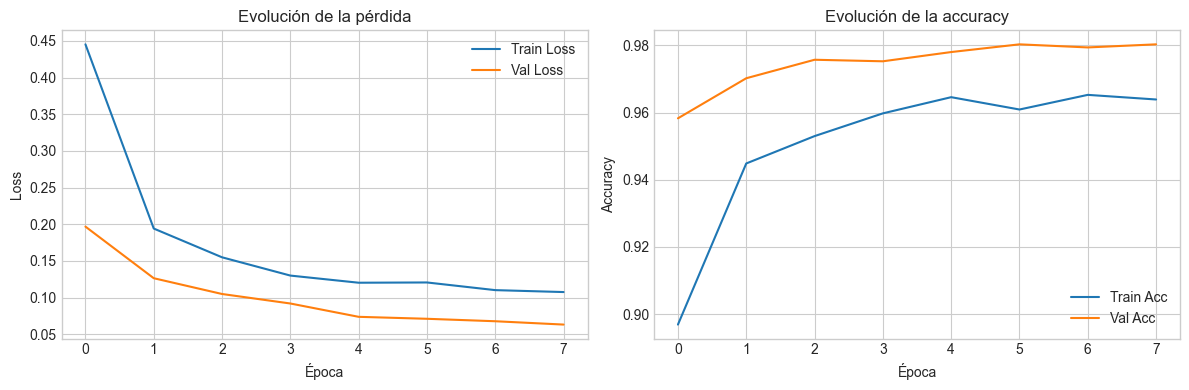

In [7]:
if train_dir.exists() and test_dir.exists():
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.title('Evolución de la pérdida')
    plt.xlabel('Época')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Acc')
    plt.plot(history['val_acc'], label='Val Acc')
    plt.title('Evolución de la accuracy')
    plt.xlabel('Época')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.tight_layout()
    plt.show()

Accuracy final en test: 98.26%

Reporte de clasificación final:
               precision    recall  f1-score   support

  freshapples       0.95      0.99      0.97       395
  freshbanana       1.00      0.99      1.00       381
 freshoranges       0.99      0.98      0.98       388
 rottenapples       0.98      0.96      0.97       601
 rottenbanana       0.99      1.00      1.00       530
rottenoranges       0.98      0.97      0.98       403

     accuracy                           0.98      2698
    macro avg       0.98      0.98      0.98      2698
 weighted avg       0.98      0.98      0.98      2698



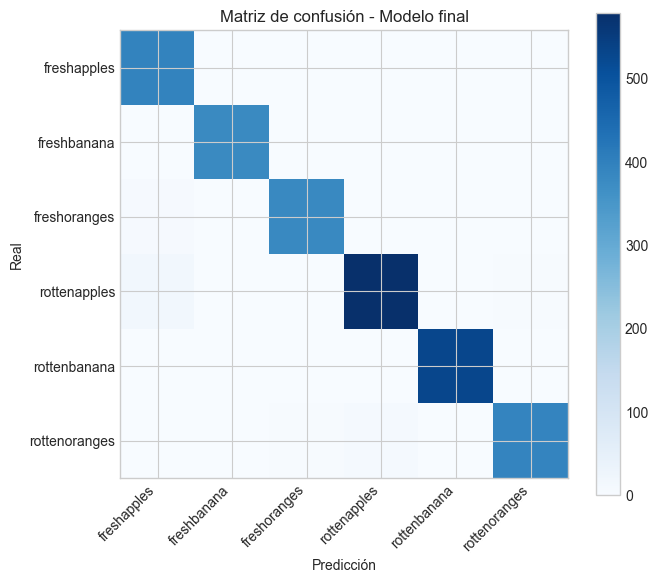

In [9]:
if train_dir.exists() and test_dir.exists():
    checkpoint = torch.load(best_model_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.numpy())

    test_acc = accuracy_score(all_targets, all_preds)
    print(f'Accuracy final en test: {test_acc * 100:.2f}%')
    print('\nReporte de clasificación final:')
    print(classification_report(all_targets, all_preds, target_names=class_names))

    cm = confusion_matrix(all_targets, all_preds)
    plt.figure(figsize=(7, 6))
    plt.imshow(cm, cmap='Blues')
    plt.title('Matriz de confusión - Modelo final')
    plt.xticks(range(len(class_names)), class_names, rotation=45, ha='right')
    plt.yticks(range(len(class_names)), class_names)
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.colorbar()
    plt.tight_layout()
    plt.show()